In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


# 1. Загрузите изображение в оттенках серого sar_1_gray.jpg. 

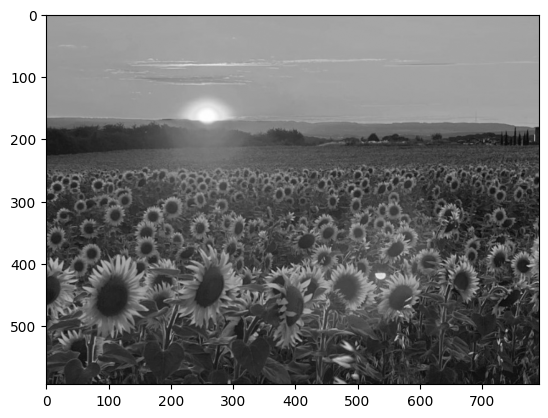

In [2]:
import cv2
image = cv2.imread('img_task1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap = 'gray')

# 2. постройте гистограмму

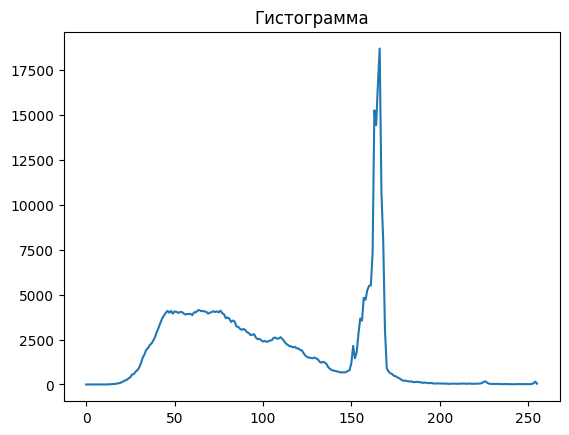

In [3]:
histSize = 256
histRange = (0, 256)
accumulate = False

hist = cv2.calcHist([image_gray], [0], None, [histSize], histRange, accumulate=accumulate)
plt.title('Гистограмма')
plt.plot(hist)

# 3. реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.

In [4]:
def gamma_cor(image, gamma):
    tmp = image.astype(np.uint8)
    tmp = tmp / 255.0
    tmp = np.power(tmp, gamma)
    res  = tmp * 255.0
    return res.astype(np.uint8)

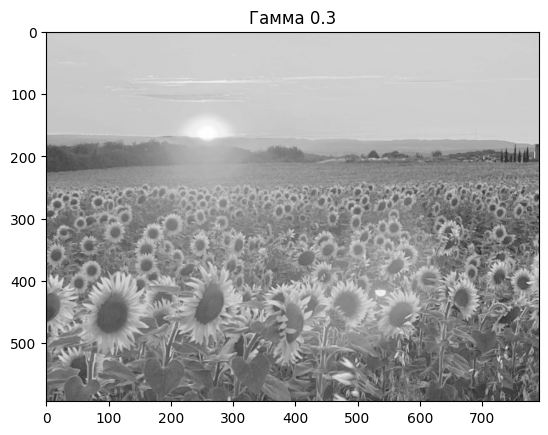

In [5]:
img_gamma_less = gamma_cor(image_gray, 0.3)

plt.title('Гамма 0.3')
plt.imshow(img_gamma_less, cmap = 'gray')

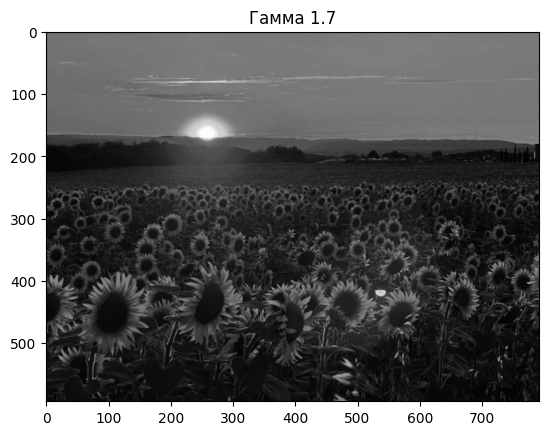

In [6]:
img_gamma_more = gamma_cor(image_gray, 1.7)

plt.title('Гамма 1.7')
plt.imshow(img_gamma_more, cmap = 'gray')

# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.

In [7]:
from skimage.metrics import structural_similarity, mean_squared_error

MSE: 7670.566160340782, SSIM: 0.7497999193997912


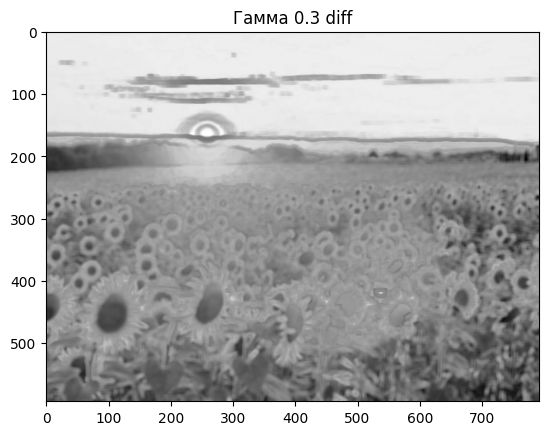

In [8]:
(ssim, diff) = structural_similarity(image_gray, img_gamma_less, full=True)
diff = (diff * 255).astype('uint8')
mse = mean_squared_error(img_gamma_less, image_gray)

print("MSE: {}, SSIM: {}".format(mse, ssim))

plt.title('Гамма 0.3 diff')
plt.imshow(diff, cmap = 'gray')

MSE: 1836.7176053463932, SSIM: 0.776704796035883


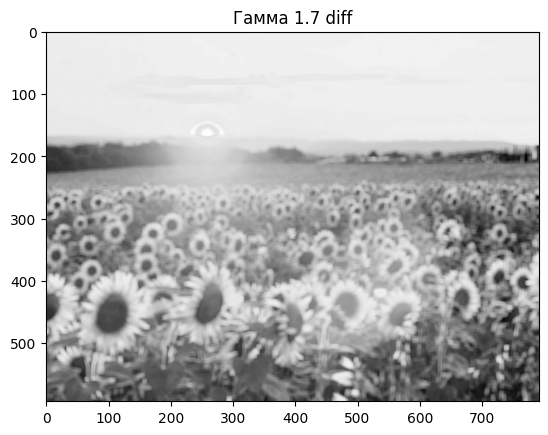

In [9]:
(ssim, diff) = structural_similarity(image_gray, img_gamma_more, full=True)
diff = (diff * 255).astype('uint8')
mse = mean_squared_error(img_gamma_more, image_gray)

print('MSE: {}, SSIM: {}'.format(mse, ssim))

plt.title('Гамма 1.7 diff')
plt.imshow(diff, cmap = 'gray')

# 5. реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.

In [10]:
def statistic_color_cor(image, cor):
    mean_i = image.mean()
    std_i = image.std()
    mean_e = eq_gray.mean()
    std_e = eq_gray.std()

    res = (image - mean_i) * (std_e/std_i) + mean_e
    return res.astype(np.uint8)

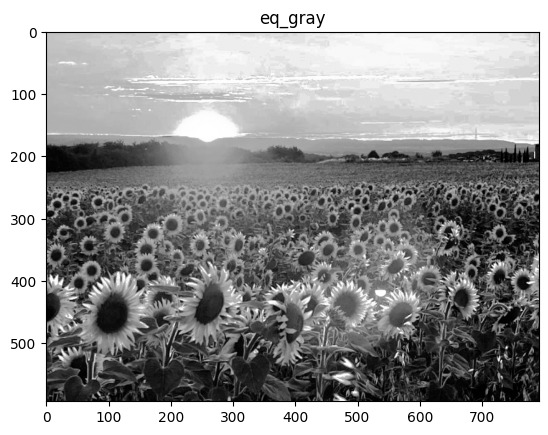

In [11]:
eq_gray = cv2.equalizeHist(image_gray)

plt.title('eq_gray')
plt.imshow(eq_gray, cmap = 'gray')

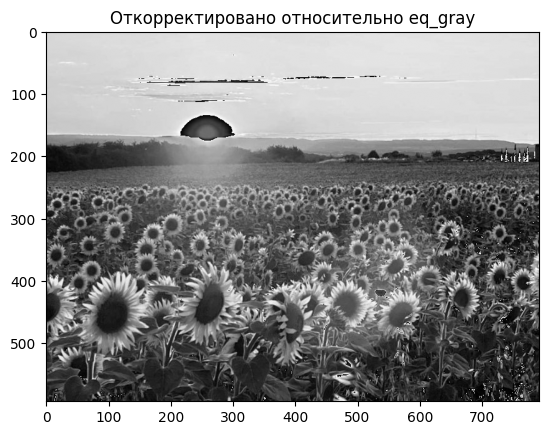

In [12]:
plt.title('Откорректировано относительно eq_gray')
plt.imshow(statistic_color_cor(image_gray, eq_gray), cmap = 'gray')

# 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.

In [13]:
def use_filter(image, f):
    arr = [50, 100, 150]
    _, plots = plt.subplots(1, 3, figsize=(10, 3))
    
    for i in range(0, 3):
        plots[i].set_title('{}'.format(arr[i]))
        _, im = cv2.threshold(image, arr[i], 255, f)
        plots[i].imshow(im, cmap = 'gray')

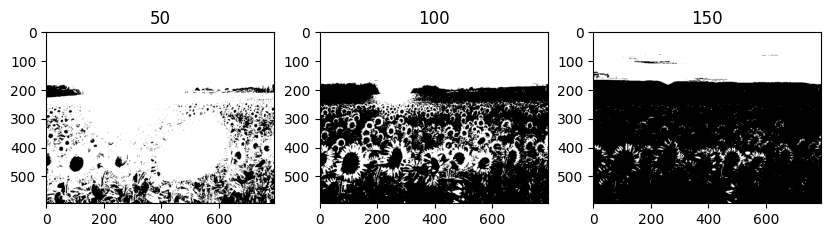

In [14]:
use_filter(image_gray, cv2.THRESH_BINARY)

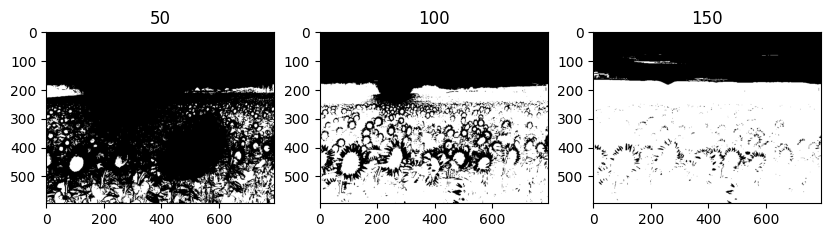

In [15]:
use_filter(image_gray, cv2.THRESH_BINARY_INV)

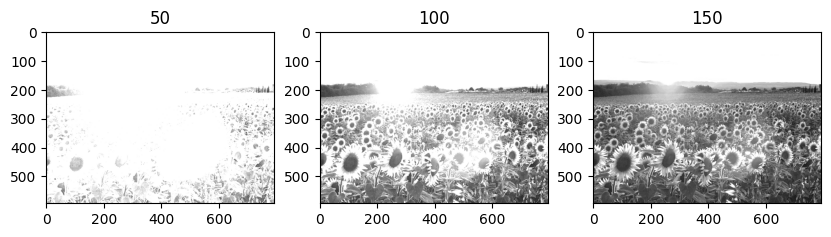

In [16]:
use_filter(image_gray, cv2.THRESH_TRUNC)

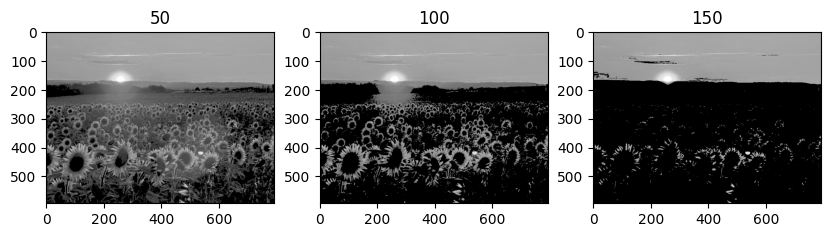

In [17]:
use_filter(image_gray, cv2.THRESH_TOZERO)

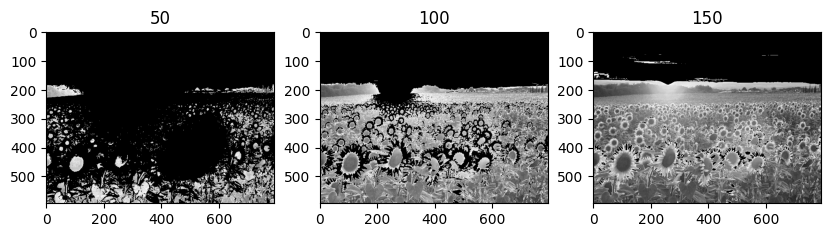

In [18]:
use_filter(image_gray, cv2.THRESH_TOZERO_INV)